# Comparing Observable to Sliced Wasserstein Distance

This notebook explains the basic code for Observable Wasserstein Distance and compares it to sliced Wasserstein distance in a simple experiment.

In [1]:
import numpy as np
import ot
import matplotlib.pyplot as plt
import time

# Preliminaries

We first set up the basic data generation and distance computation functions.

## Gaussian Data

We'll primarily use Gaussian data in this notebook. The following is a helper function for generating data. Everything will be done with respect to fixed random number generators, for reproducibility.

In [49]:
def generate_gaussian_data(mean, cov, n_samples, rng):
    
    data = rng.multivariate_normal(mean,cov,size=n_samples)
    
    return data

## Computing Distances

Now we define observable and sliced Wasserstein distances. The implementations here are as simple as possible, and are specific to the situation of empirical measures, in Euclidean space, with an equal number of points. 

The version of observable Wasserstein distance used here uses 'distance-to-a-point' functions as observables, and the anchor points are randomly sampled from a symmetric, mean-zero Gaussian with a chosen variance.

For sliced Wasserstein distance, we use randomly sampled directions.

In [53]:
def sample_random_directions(dim, num_projections, rng):
    
    dirs = rng.normal(size=(num_projections, dim))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dirs = dirs / np.maximum(norms, 1e-12)
    
    return dirs

def sample_random_anchors(dim, num_anchors, variance, rng):
    
    mean = np.zeros(dim)
    cov = variance*np.eye(dim)
    
    anchors = rng.multivariate_normal(mean, cov, num_anchors)
    
    return anchors

Now we define the distances with respect to these choices.

In [77]:
def sliced_wasserstein_distance(A, B, directions):

    proj_A = A @ directions.T
    proj_B = B @ directions.T

    proj_A.sort(axis=0)
    proj_B.sort(axis=0)

    diffs = np.abs(proj_A - proj_B)
    per_direction_costs = np.mean(diffs, axis=0)
    
    return np.max(per_direction_costs)

In [79]:
from sklearn.metrics.pairwise import pairwise_distances

def observable_wasserstein_distance(A, B, anchors):

    D_A = pairwise_distances(A, anchors)
    D_B = pairwise_distances(B, anchors)

    D_A.sort(axis=0)
    D_B.sort(axis=0)

    diffs = np.abs(D_A - D_B)
    per_observable_costs = np.mean(diffs, axis=0)

    return float(np.max(per_observable_costs))

## Testing

Let's test the code so far.

In [94]:
## Parameters
dimension = 3
mean = np.zeros(dimension)
cov = np.eye(dimension)
n_samples = 1000

num_projections = 100
num_anchors = 100
variance = 1

## Generating Data
rngA = np.random.default_rng(0)
A = generate_gaussian_data(mean,cov,n_samples,rngA)
rngB = np.random.default_rng(1)
B = generate_gaussian_data(mean,cov,n_samples,rngB)

directions = sample_random_directions(dimension,num_projections,rngA)
anchors = sample_random_anchors(dimension,num_anchors,variance, rngA)

In [95]:
%time
sliced_wasserstein_distance(A,B,directions)

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 3.81 µs


0.12315756593644675

In [96]:
%time
observable_wasserstein_distance(A,B,anchors)

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 4.77 µs


0.10890042310316571

Comparing to full Wasserstein distance:

In [97]:
%time
a = ot.unif(len(A))
b = ot.unif(len(B))
M = pairwise_distances(A,B)

ot.emd2(a,b,M)

CPU times: user 5 µs, sys: 3 µs, total: 8 µs
Wall time: 98 µs


0.33380656519157914

Comparing to the Python Optimal Transport implementation of sliced Wasserstein distance:

In [98]:
%time
ot.sliced.max_sliced_wasserstein_distance(A, B, p=1, projections = directions.T)

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 4.77 µs


0.1231575659364469

# Main Experiment

Now we run a more formal experiment to compare the various notions of distance in a simple classification task.

We generate empirical distributions from Gaussians in a fixed dimension. The come in three classes, defined by altering the covariance matrix structure. We will test the ability of each distance to distinguish the classes through 1-nearest neighbor classification rates.

=== Running dimension d=2 ===
[dim=2] run 1/10 done
[dim=2] run 2/10 done
[dim=2] run 3/10 done
[dim=2] run 4/10 done
[dim=2] run 5/10 done
[dim=2] run 6/10 done
[dim=2] run 7/10 done
[dim=2] run 8/10 done
[dim=2] run 9/10 done
[dim=2] run 10/10 done
=== Running dimension d=5 ===
[dim=5] run 1/10 done
[dim=5] run 2/10 done
[dim=5] run 3/10 done
[dim=5] run 4/10 done
[dim=5] run 5/10 done
[dim=5] run 6/10 done
[dim=5] run 7/10 done
[dim=5] run 8/10 done
[dim=5] run 9/10 done
[dim=5] run 10/10 done
=== Running dimension d=10 ===
[dim=10] run 1/10 done
[dim=10] run 2/10 done
[dim=10] run 3/10 done
[dim=10] run 4/10 done
[dim=10] run 5/10 done
[dim=10] run 6/10 done
[dim=10] run 7/10 done
[dim=10] run 8/10 done
[dim=10] run 9/10 done
[dim=10] run 10/10 done
=== Running dimension d=25 ===
[dim=25] run 1/10 done
[dim=25] run 2/10 done
[dim=25] run 3/10 done
[dim=25] run 4/10 done
[dim=25] run 5/10 done
[dim=25] run 6/10 done
[dim=25] run 7/10 done
[dim=25] run 8/10 done
[dim=25] run 9/10 don

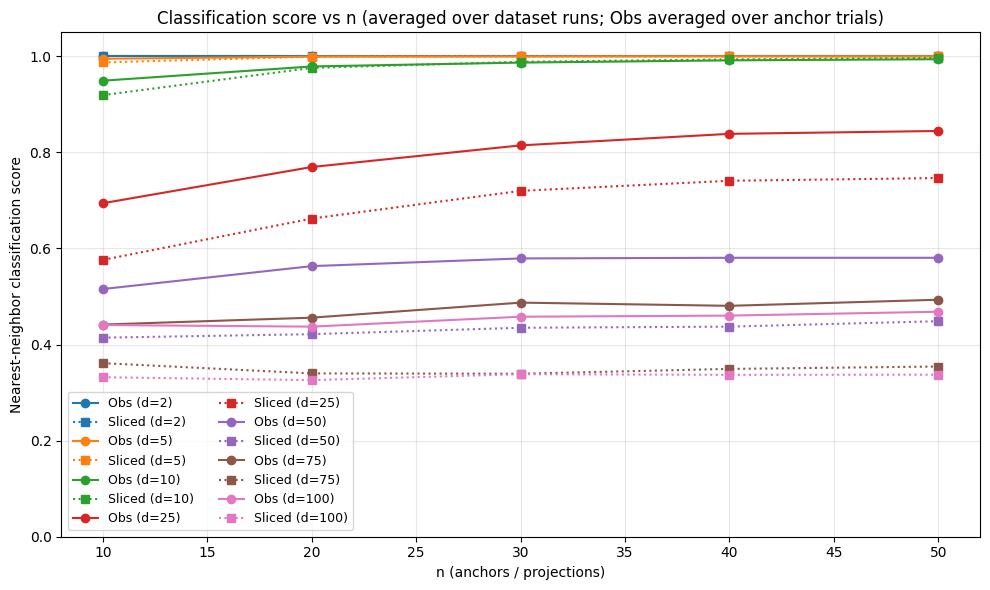

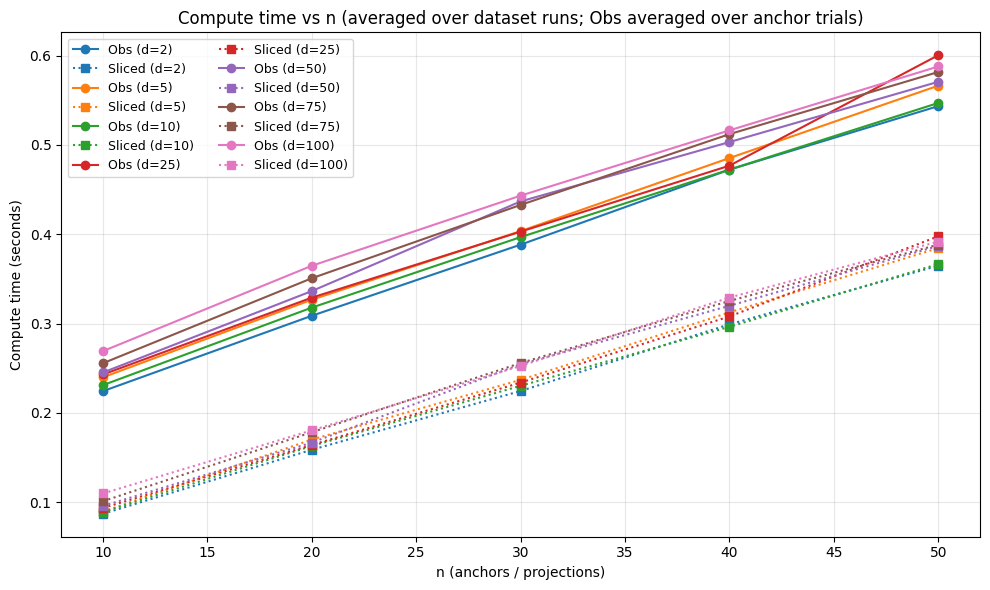

In [99]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances
import ot 

# ---------------------------------------------------------------------
# EXPERIMENT PARAMETERS (easy to tweak)
# ---------------------------------------------------------------------

# Dimensions to test
dimensions = [2,5,10,25,50,75,100]

# "num_slices" values (also used as #anchors for Observable-W, and #projections for Sliced-W)
num_slices_list = [10,20,30,40,50]

# Dataset generation
num_samples_per_class = 10
base_n_points = 250
dataset_seed_base = 12345    # used to reproducibly vary seeds across

# Class covariances: Class1 I, Class2 inflates coord 0, Class3 inflates coord (d-1)
inflation_value = 3.0

# Observable Wasserstein specifics
num_anchor_trials = 10        # per dataset-run, average over these different anchor sets
anchor_cov_scale = 5.0       # anchors ~ N(0, anchor_cov_scale * I)

# Number of dataset resampling runs per dimension
num_dataset_runs = 10

# Plot controls
figsize = (10, 6)
score_ylim = (0.0, 1.05)

# ---------------------------------------------------------------------
# CLASSIFICATION FUNCTION
# ---------------------------------------------------------------------

def nearest_classification(D,num_samples_per_class,labels):
    
    score = np.sum(np.floor(np.argsort(D,axis=1)/num_samples_per_class)[:,1] == labels)
    
    return score/len(labels)

# ---------------------------------------------------------------------
# HELPER FUNCTIONS
# ---------------------------------------------------------------------


def make_labels(num_samples_per_class: int):
    return ([0] * num_samples_per_class +
            [1] * num_samples_per_class +
            [2] * num_samples_per_class)


def generate_dataset_for_dimension(dimension: int, rng: np.random.Generator):
    """Generate 3-class dataset with specified covariance structure."""
    dataset = []
    mean = np.zeros(dimension)

    # Class 1: N(0, I)
    cov1 = np.eye(dimension)

    # Class 2: N(0, diag([inflation_value, 1, ..., 1]))
    cov2 = np.eye(dimension)
    cov2[0, 0] = inflation_value

    # Class 3: N(0, diag([1, ..., 1, inflation_value]))
    cov3 = np.eye(dimension)
    cov3[dimension - 1, dimension - 1] = inflation_value

    for _ in range(num_samples_per_class):
        dataset.append(generate_gaussian_data(mean, cov1, base_n_points, rng))

    for _ in range(num_samples_per_class):
        dataset.append(generate_gaussian_data(mean, cov2, base_n_points, rng))

    for _ in range(num_samples_per_class):
        dataset.append(generate_gaussian_data(mean, cov3, base_n_points, rng))

    return dataset


def compute_observable_distance_matrix(dataset, anchors):
    """Compute full symmetric distance matrix for Observable Wasserstein."""
    m = len(dataset)
    D = np.zeros((m, m), dtype=float)

    for i in range(m):
        for j in range(i + 1, m):
            D[i, j] = observable_wasserstein_distance(dataset[i],dataset[j],anchors)
    D = D + D.T
    return D


def compute_sliced_distance_matrix(dataset, directions):
    """Compute full symmetric distance matrix for max sliced Wasserstein."""
    m = len(dataset)
    D = np.zeros((m, m), dtype=float)

    for i in range(m):
        for j in range(i + 1, m):
            D[i, j] = sliced_wasserstein_distance(dataset[i],dataset[j],directions)
    D = D + D.T
    return D


def run_experiment_for_dimension(dimension: int):
    """
    For a fixed dimension:
      - repeat num_dataset_runs times with resampled dataset
      - for each dataset-run:
          * Observable: for each n in num_slices_list:
              average over num_anchor_trials random anchor sets (score + time)
          * Sliced: for each n in num_slices_list:
              compute once (score + time)
    Returns:
      dict with mean/std arrays over dataset-runs for score/time (observable & sliced),
      where observable already averages over anchor trials within each run.
    """
    labels = make_labels(num_samples_per_class)

    # Collect per-run results: shape (num_dataset_runs, len(num_slices_list))
    obs_scores_runs = np.zeros((num_dataset_runs, len(num_slices_list)))
    obs_times_runs  = np.zeros((num_dataset_runs, len(num_slices_list)))
    slc_scores_runs = np.zeros((num_dataset_runs, len(num_slices_list)))
    slc_times_runs  = np.zeros((num_dataset_runs, len(num_slices_list)))

    for run_idx in range(num_dataset_runs):
        # dataset RNG (changes dataset each run)
        rng_data = np.random.default_rng(dataset_seed_base + 10_000 * dimension + run_idx)
        dataset = generate_dataset_for_dimension(dimension, rng_data)

        # For each n in num_slices_list
        for k, n_slices in enumerate(num_slices_list):

            # -------------------------
            # Observable Wasserstein:
            # average across anchor trials
            # -------------------------
            obs_trial_scores = []
            obs_trial_times = []

            for t in range(num_anchor_trials):
                rng_anchor = np.random.default_rng(
                    dataset_seed_base + 10_000 * dimension + 100 * run_idx + t
                )

                mean = np.zeros(dimension)
                cov = (anchor_cov_scale) * np.eye(dimension)
                anchors = rng_anchor.multivariate_normal(mean, cov, size=n_slices)

                start = time.perf_counter()
                D_obs = compute_observable_distance_matrix(dataset, anchors)
                elapsed = time.perf_counter() - start

                score = nearest_classification(D_obs,num_samples_per_class, labels)
                obs_trial_scores.append(score)
                obs_trial_times.append(elapsed)

            obs_scores_runs[run_idx, k] = float(np.mean(obs_trial_scores))
            obs_times_runs[run_idx, k]  = float(np.mean(obs_trial_times))

            # -------------------------
            # Sliced Wasserstein:
            # average across direction trials
            # -------------------------
            
            slc_trial_scores = []
            slc_trial_times = []

            for t in range(num_anchor_trials):
                rng_anchor = np.random.default_rng(
                    dataset_seed_base + 10_000 * dimension + 100 * run_idx + t
                )

                directions = sample_random_directions(dimension, n_slices, rng_anchor)

                start = time.perf_counter()
                D_slc = compute_sliced_distance_matrix(dataset, directions)
                elapsed = time.perf_counter() - start

                score = nearest_classification(D_slc,num_samples_per_class, labels)
                slc_trial_scores.append(score)
                slc_trial_times.append(elapsed)

            slc_scores_runs[run_idx, k] = float(np.mean(slc_trial_scores))
            slc_times_runs[run_idx, k]  = float(np.mean(slc_trial_times))
            

        print(f"[dim={dimension}] run {run_idx+1}/{num_dataset_runs} done")

    out = {
        "obs_score_mean": obs_scores_runs.mean(axis=0),
        "obs_score_std":  obs_scores_runs.std(axis=0, ddof=1) if num_dataset_runs > 1 else np.zeros(len(num_slices_list)),
        "obs_time_mean":  obs_times_runs.mean(axis=0),
        "obs_time_std":   obs_times_runs.std(axis=0, ddof=1) if num_dataset_runs > 1 else np.zeros(len(num_slices_list)),

        "slc_score_mean": slc_scores_runs.mean(axis=0),
        "slc_score_std":  slc_scores_runs.std(axis=0, ddof=1) if num_dataset_runs > 1 else np.zeros(len(num_slices_list)),
        "slc_time_mean":  slc_times_runs.mean(axis=0),
        "slc_time_std":   slc_times_runs.std(axis=0, ddof=1) if num_dataset_runs > 1 else np.zeros(len(num_slices_list)),
    }
    return out


def plot_results(all_results_by_dim):
    """
    Make two plots:
      1) classification score vs num_slices
      2) compute time vs num_slices
    Color-coded by dimension; solid = Observable, dotted = Sliced.
    """
    # Choose a colormap for distinct dimension colors
    cmap = plt.get_cmap("tab10")
    colors = {d: cmap(i % 10) for i, d in enumerate(dimensions)}

    # --- Plot 1: Scores ---
    plt.figure(figsize=figsize)
    for d in dimensions:
        res = all_results_by_dim[d]
        c = colors[d]

        # Observable (solid)
        plt.plot(num_slices_list, res["obs_score_mean"], linestyle="-", marker="o",
                 label=f"Obs (d={d})", color=c)
        # Sliced (dotted)
        plt.plot(num_slices_list, res["slc_score_mean"], linestyle=":", marker="s",
                 label=f"Sliced (d={d})", color=c)

    plt.xlabel("n (anchors / projections)")
    plt.ylabel("Nearest-neighbor classification score")
    plt.ylim(*score_ylim)
    plt.title("Classification score vs n (averaged over dataset runs; Obs averaged over anchor trials)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    # --- Plot 2: Times ---
    plt.figure(figsize=figsize)
    for d in dimensions:
        res = all_results_by_dim[d]
        c = colors[d]

        plt.plot(num_slices_list, res["obs_time_mean"], linestyle="-", marker="o",
                 label=f"Obs (d={d})", color=c)
        plt.plot(num_slices_list, res["slc_time_mean"], linestyle=":", marker="s",
                 label=f"Sliced (d={d})", color=c)

    plt.xlabel("n (anchors / projections)")
    plt.ylabel("Compute time (seconds)")
    plt.title("Compute time vs n (averaged over dataset runs; Obs averaged over anchor trials)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    plt.show()


# ---------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------

if __name__ == "__main__":
    all_results_by_dim = {}
    for d in dimensions:
        print(f"=== Running dimension d={d} ===")
        all_results_by_dim[d] = run_experiment_for_dimension(d)

    plot_results(all_results_by_dim)


## Creating Final Figures for the Paper

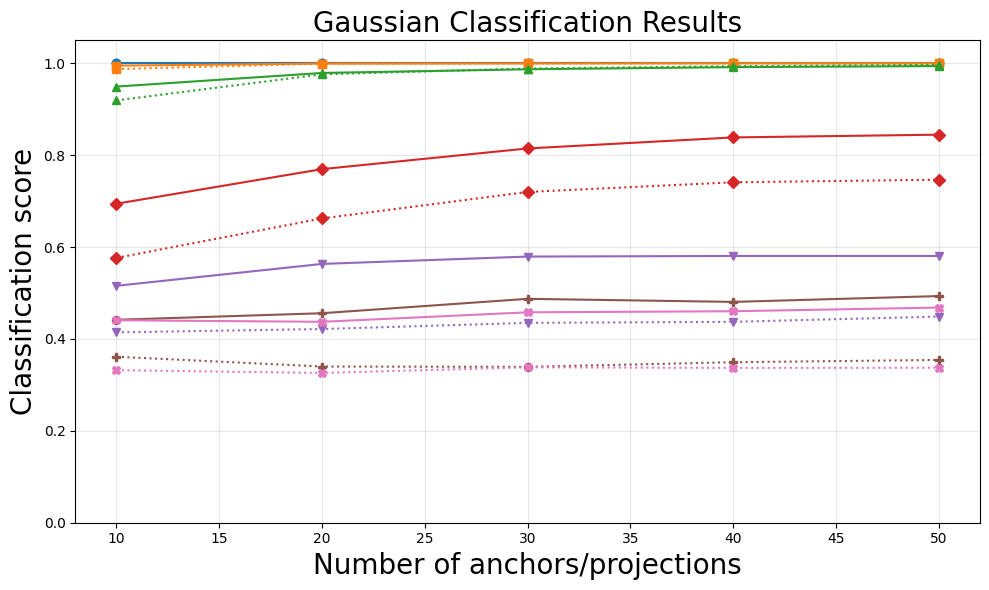

In [103]:
figsize = (10,6)

plt.figure(figsize=figsize)

fontsize = 20
cmap = plt.get_cmap("tab10")
colors = {d: cmap(i % 10) for i, d in enumerate(dimensions)}

# Pick a marker per dimension (cycle if you have more dims than markers)
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', 'p']
markers = {d: marker_cycle[i % len(marker_cycle)] for i, d in enumerate(dimensions)}

for d in dimensions:
    res = all_results_by_dim[d]
    c = colors[d]
    m = markers[d]

    # Obs (solid)
    plt.plot(
        num_slices_list, res["obs_score_mean"],
        linestyle="-", marker=m, color=c,
        label=f"Obs (d={d})"
    )

    # Sliced (dotted)
    plt.plot(
        num_slices_list, res["slc_score_mean"],
        linestyle=":", marker=m, color=c,
        label=f"Sliced (d={d})"
    )

plt.xlabel("Number of anchors/projections", fontsize=fontsize)
plt.ylabel("Classification score", fontsize=fontsize)
plt.ylim(*score_ylim)
plt.title("Gaussian Classification Results", fontsize=fontsize)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('GaussianClassificationResults.png',dpi=300)

plt.show()

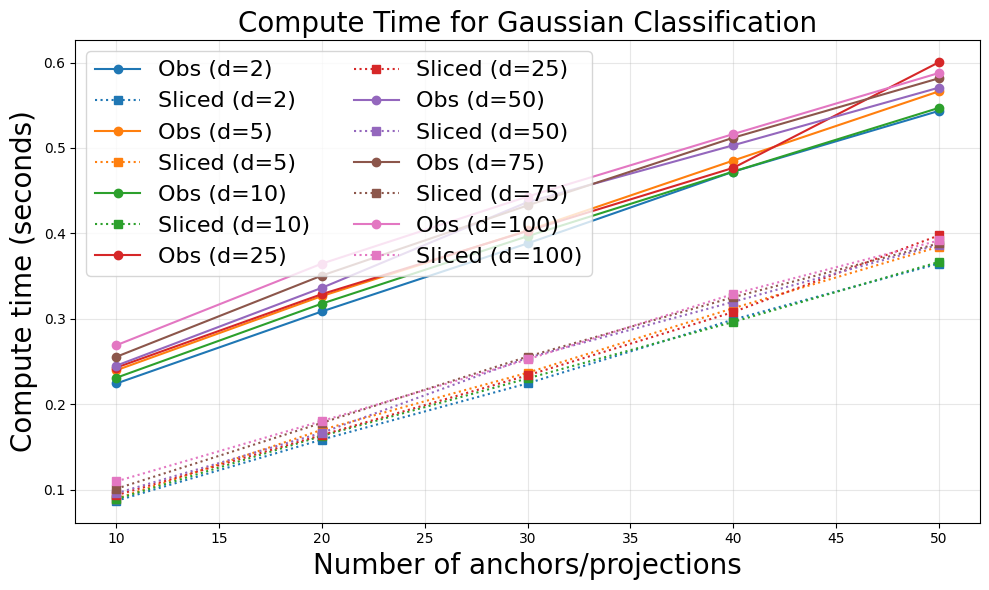

In [102]:
plt.figure(figsize=figsize)

for d in dimensions:
    res = all_results_by_dim[d]
    c = colors[d]

    plt.plot(num_slices_list, res["obs_time_mean"], linestyle="-", marker="o",
             label=f"Obs (d={d})", color=c)
    plt.plot(num_slices_list, res["slc_time_mean"], linestyle=":", marker="s",
             label=f"Sliced (d={d})", color=c)

plt.xlabel("Number of anchors/projections",fontsize=fontsize)
plt.ylabel("Compute time (seconds)",fontsize=fontsize)
plt.title("Compute Time for Gaussian Classification",fontsize=fontsize)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=16)
plt.tight_layout()

plt.savefig('GaussianComputeTime.png',dpi=300)
plt.show()